In [51]:
import pandas as pd

# Load CSV
df = pd.read_csv("results.csv")

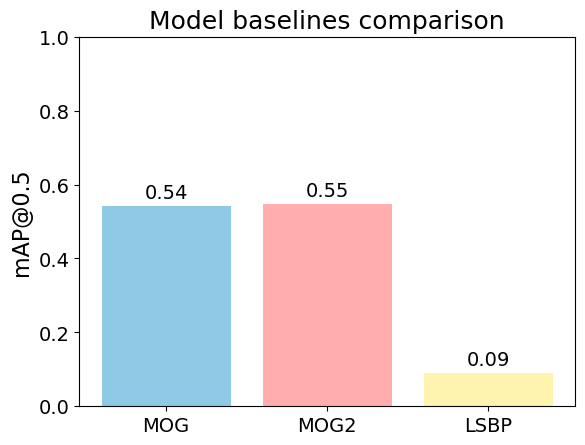

In [53]:
# Filter subtype = none
df_none = df[df["subtype"] == "none"]

# Convert model names to uppercase
models_upper = df_none["model"].str.upper()

# Light pastel colors
colors = ["#8ecae6", "#ffadad", "#fff3b0"]

plt.figure()

bars = plt.bar(models_upper, df_none["mAP50"], color=colors)

plt.ylabel("mAP@0.5", fontsize=16)
plt.title("Model baselines comparison", fontsize=18)
plt.ylim(0, 1)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,
             f"{height:.2f}", ha='center', va='bottom', fontsize=14)

plt.show()

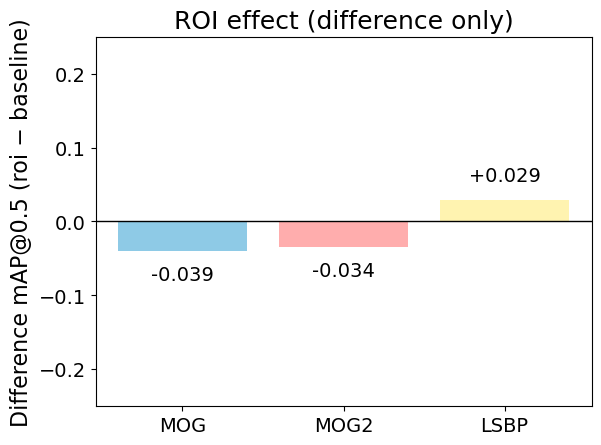

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("results.csv")
df.columns = df.columns.str.strip()
df["mAP50"] = df["mAP50"].astype(str).str.replace(",", ".").astype(float)

# One row per model, columns are subtypes
p = df.pivot_table(index="model", columns="subtype", values="mAP50", aggfunc="first")

# Keep only models that have both values
p = p.dropna(subset=["none", "roi"])

diff = p["roi"] - p["none"]

# Desired order
order = ["mog", "mog2", "lsbp"]

# Keep only models that exist and reorder
diff = diff.reindex(order)

# Convert index to uppercase for plotting
diff.index = diff.index.str.upper()

colors_map = {"mog": "#8ecae6", "mog2": "#ffadad", "lsbp": "#fff3b0"}
colors = [colors_map.get(m.lower(), "#cccccc") for m in diff.index]

plt.figure()  # keep default dimensions

plt.axhline(0, color="black", linewidth=1)
bars = plt.bar(diff.index, diff.values, color=colors)

plt.ylim(-0.25, 0.25)
plt.ylabel("Difference mAP@0.5 (roi − baseline)", fontsize=16)
plt.title("ROI effect (difference only)", fontsize=18)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Labels on bars (bigger)
for b, v in zip(bars, diff.values):
    plt.text(
        b.get_x() + b.get_width()/2,
        v + (0.02 if v >= 0 else -0.02),
        f"{v:+.3f}",
        ha="center",
        va="bottom" if v >= 0 else "top",
        fontsize=14
    )

plt.show()

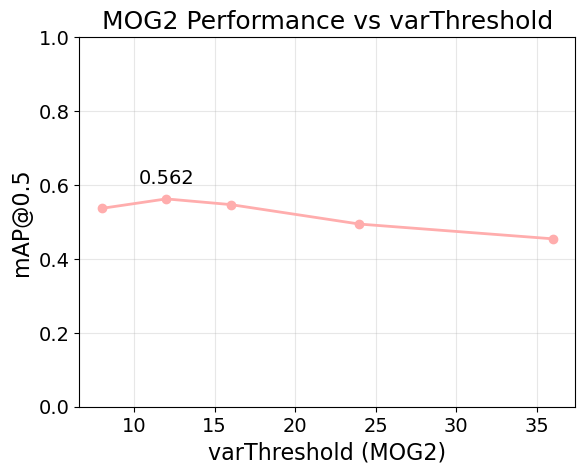

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import re

df = pd.read_csv("results.csv")
df.columns = df.columns.str.strip()
df["mAP50"] = df["mAP50"].astype(str).str.replace(",", ".").astype(float)

# Keep only threshold experiments
df_th = df[df["subtype"].str.startswith("thv")].copy()

# Extract numeric threshold value
df_th["var_threshold"] = df_th["subtype"].str.extract(r"thv(\d+)").astype(int)

# Sort by threshold
df_th = df_th.sort_values("var_threshold")

plt.figure()

plt.plot(
    df_th["var_threshold"],
    df_th["mAP50"],
    color="#ffadad",
    marker="o",
    linewidth=2
)

plt.xlabel("varThreshold (MOG2)", fontsize=16)
plt.ylabel("mAP@0.5", fontsize=16)
plt.title("MOG2 Performance vs varThreshold", fontsize=18)
plt.ylim(0, 1)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(alpha=0.3)

# Highlight highest score
max_idx = df_th["mAP50"].idxmax()
max_x = df_th.loc[max_idx, "var_threshold"]
max_y = df_th.loc[max_idx, "mAP50"]

plt.text(
    max_x,
    max_y + 0.03,
    f"{max_y:.3f}",
    ha="center",
    va="bottom",
    fontsize=14,
)

plt.show()

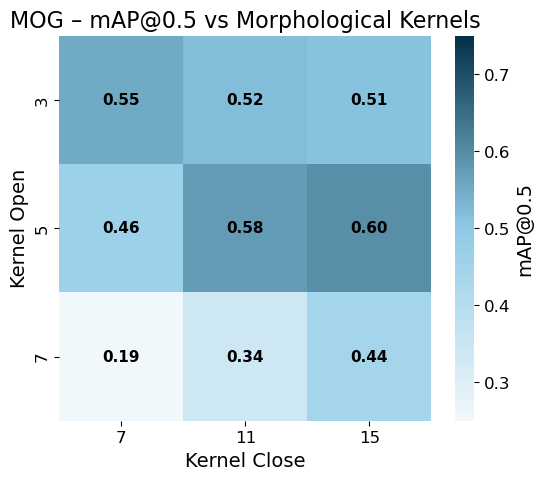

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from matplotlib.colors import LinearSegmentedColormap

# Load CSV
df = pd.read_csv("results.csv")
df.columns = df.columns.str.strip()
df["mAP50"] = df["mAP50"].astype(str).str.replace(",", ".").astype(float)

df_mog = df[df["model"] == "mog"]

# Keep only MOG open/close experiments
df_oc = df_mog[df_mog["subtype"].str.startswith("OC_")].copy()

# Extract open and close values
df_oc[["open", "close"]] = df_oc["subtype"].str.extract(r"OC_(\d+)_(\d+)").astype(int)

# Pivot to matrix
heatmap_data = df_oc.pivot(index="open", columns="close", values="mAP50")

# Sort axes
heatmap_data = heatmap_data.sort_index().sort_index(axis=1)

# Create custom colormap
base_color = "#8ecae6"
cmap = LinearSegmentedColormap.from_list(
    "custom_blue",
    ["#f1f8fb", base_color, "#023047"]
)

plt.figure(figsize=(6,5))

ax = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    vmin=0.25,
    vmax=0.75,
    cbar_kws={"label": "mAP@0.5"},
    annot_kws={
        "color": "black",
        "weight": "bold",
        "size": 11   # unchanged (inside heatmap)
    }
)

# Increase external text sizes
ax.set_title("MOG – mAP@0.5 vs Morphological Kernels", fontsize=16)
ax.set_xlabel("Kernel Close", fontsize=14)
ax.set_ylabel("Kernel Open", fontsize=14)

ax.tick_params(axis='both', labelsize=12)

# Increase colorbar label and ticks
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
cbar.set_label("mAP@0.5", fontsize=14)

plt.show()

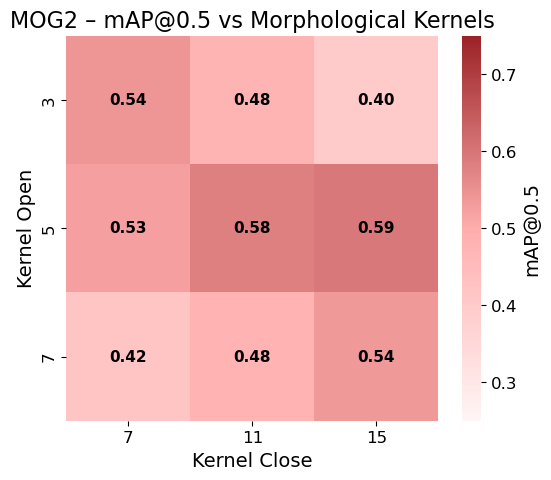

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from matplotlib.colors import LinearSegmentedColormap

# Load CSV
df = pd.read_csv("results.csv")
df.columns = df.columns.str.strip()
df["mAP50"] = df["mAP50"].astype(str).str.replace(",", ".").astype(float)

df_mog2 = df[df["model"] == "mog2"]

# Keep only MOG2 open/close experiments
df_oc = df_mog2[df_mog2["subtype"].str.startswith("OC_")].copy()

# Extract open and close values
df_oc[["open", "close"]] = df_oc["subtype"].str.extract(r"OC_(\d+)_(\d+)").astype(int)

# Pivot to matrix
heatmap_data = df_oc.pivot(index="open", columns="close", values="mAP50")

# Sort axes
heatmap_data = heatmap_data.sort_index().sort_index(axis=1)

# Create custom colormap
base_color = "#ffadad"
cmap = LinearSegmentedColormap.from_list(
    "custom_red",
    ["#fff5f5", base_color, "#9b2226"]
)

plt.figure(figsize=(6,5))

ax = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    vmin=0.25,
    vmax=0.75,
    cbar_kws={"label": "mAP@0.5"},
    annot_kws={
        "color": "black",
        "weight": "bold",
        "size": 11  # unchanged (inside heatmap)
    }
)

# Increase external text sizes
ax.set_title("MOG2 – mAP@0.5 vs Morphological Kernels", fontsize=16)
ax.set_xlabel("Kernel Close", fontsize=14)
ax.set_ylabel("Kernel Open", fontsize=14)

ax.tick_params(axis='both', labelsize=12)

# Increase colorbar text size
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
cbar.set_label("mAP@0.5", fontsize=14)

plt.show()

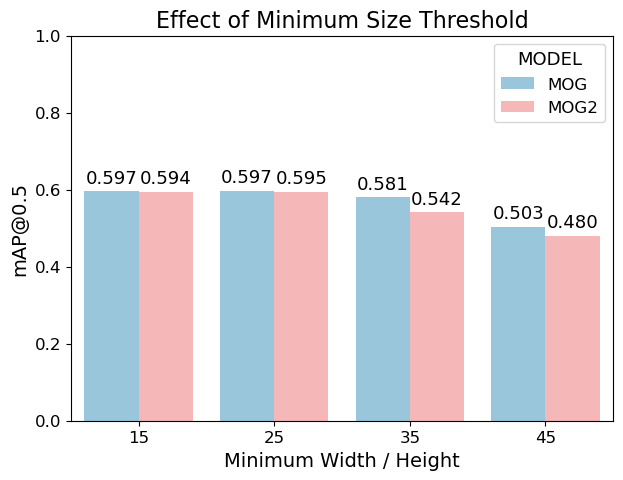

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSV
df = pd.read_csv("results.csv")
df.columns = df.columns.str.strip()

# Fix decimal commas if needed
df["mAP50"] = df["mAP50"].astype(str).str.replace(",", ".").astype(float)

# Keep only min_ experiments
df_min = df[df["subtype"].str.startswith("min_")].copy()

# Extract numeric min value
df_min["min_size"] = df_min["subtype"].str.extract(r"min_(\d+)").astype(int)

# Sort by min_size
df_min = df_min.sort_values("min_size")

# Convert legend labels to uppercase
df_min["model"] = df_min["model"].str.upper()

palette = {
    "MOG": "#8ecae6",
    "MOG2": "#ffadad"
}

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=df_min,
    x="min_size",
    y="mAP50",
    hue="model",
    palette=palette
)

plt.ylim(0, 1)

# Slightly smaller axis text
ax.set_ylabel("mAP@0.5", fontsize=14)
ax.set_xlabel("Minimum Width / Height", fontsize=14)
ax.set_title("Effect of Minimum Size Threshold", fontsize=16)

ax.tick_params(axis='both', labelsize=12)

legend = ax.legend(title="MODEL", fontsize=12, title_fontsize=13)

# Bigger value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=13)

plt.show()

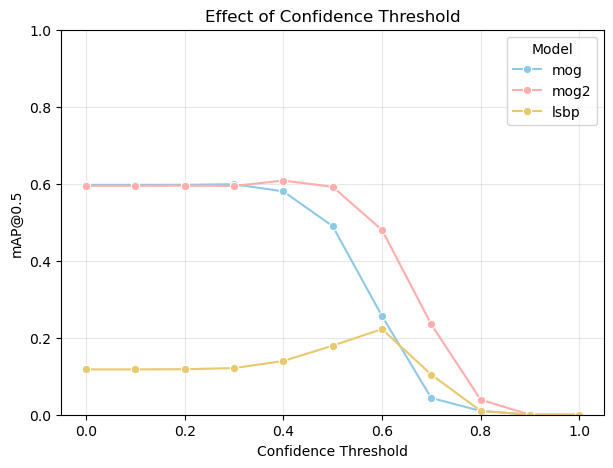

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Load CSV
df = pd.read_csv("results.csv")
df.columns = df.columns.str.strip()

# Keep only confidence experiments
df_conf = df[df["subtype"].str.startswith("conf_")].copy()

# Extract numeric confidence
df_conf["conf"] = df_conf["subtype"].str.extract(r"conf_(\d+\.\d+)").astype(float)

# Sort properly
df_conf = df_conf.sort_values("conf")

# Model colors (same as before)
palette = {
    "mog": "#8ecae6",    # light blue
    "mog2": "#ffadad",   # light red
    "lsbp": "#e8c96e",    # light yellow
}

plt.figure(figsize=(7,5))

sns.lineplot(
    data=df_conf,
    x="conf",
    y="mAP50",
    hue="model",
    marker="o",
    palette=palette
)

plt.ylim(0, 1)
plt.xlabel("Confidence Threshold")
plt.ylabel("mAP@0.5")
plt.title("Effect of Confidence Threshold")
plt.legend(title="Model")

plt.grid(alpha=0.3)
plt.show()

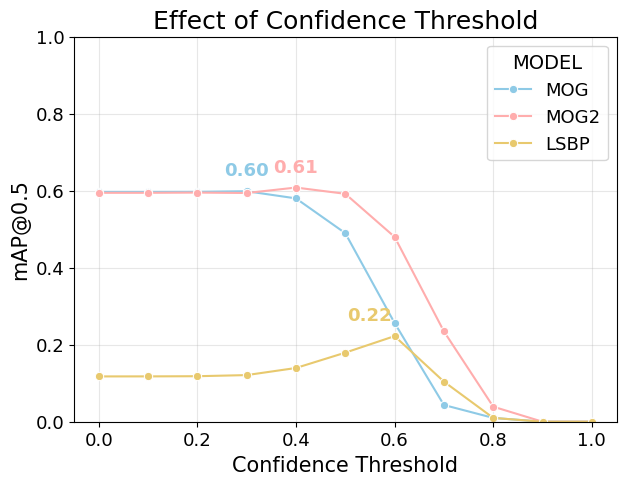

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Load CSV
df = pd.read_csv("results.csv")
df.columns = df.columns.str.strip()

# Keep only confidence experiments
df_conf = df[df["subtype"].str.startswith("conf_")].copy()

# Extract numeric confidence
df_conf["conf"] = df_conf["subtype"].str.extract(r"conf_(\d+\.\d+)").astype(float)

# Sort properly
df_conf = df_conf.sort_values("conf")

# Uppercase model names for legend
df_conf["model"] = df_conf["model"].str.upper()

# Model colors (uppercase keys now)
palette = {
    "MOG": "#8ecae6",
    "MOG2": "#ffadad",
    "LSBP": "#e8c96e",
}

plt.figure(figsize=(7,5))

ax = sns.lineplot(
    data=df_conf,
    x="conf",
    y="mAP50",
    hue="model",
    marker="o",
    palette=palette
)

plt.ylim(0, 1)

ax.set_xlabel("Confidence Threshold", fontsize=15)
ax.set_ylabel("mAP@0.5", fontsize=15)
ax.set_title("Effect of Confidence Threshold", fontsize=18)

ax.tick_params(axis='both', labelsize=13)

legend = ax.legend(title="MODEL", fontsize=13, title_fontsize=14)

plt.grid(alpha=0.3)

# ---- Highlight highest point per model ----
for model in df_conf["model"].unique():
    df_model = df_conf[df_conf["model"] == model]
    idx_max = df_model["mAP50"].idxmax()
    
    x_max = df_model.loc[idx_max, "conf"]
    y_max = df_model.loc[idx_max, "mAP50"]
    
    # Move LSBP label slightly to the left
    if model == "LSBP":
        x_text = x_max - 0.05   # adjust this value if needed
    else:
        x_text = x_max
    
    plt.text(
        x_text,
        y_max + 0.03,
        f"{y_max:.2f}",
        ha="center",
        va="bottom",
        fontsize=13,
        color=palette[model],
        weight="bold"
    )

plt.show()

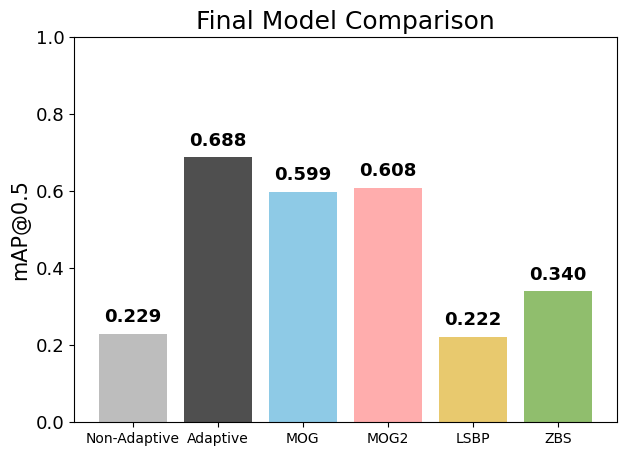

In [2]:
data_final = {"Non-Adaptive": 0.2294, "Adaptive": 0.6883, "MOG": 0.5987, "MOG2": 0.6082, "LSBP": 0.2224, "ZBS": 0.3397}
import matplotlib.pyplot as plt



# Color mapping
colors = {
    "MOG": "#8ecae6",
    "MOG2": "#ffadad",
    "LSBP": "#e8c96e",
    "ZBS": "#90be6d",
    "Non-Adaptive": "#bdbdbd",
    "Adaptive": "#4f4f4f"
}

labels = list(data_final.keys())
values = list(data_final.values())
bar_colors = [colors[label] for label in labels]

plt.figure(figsize=(7,5))

bars = plt.bar(labels, values, color=bar_colors)

plt.ylim(0, 1)
plt.ylabel("mAP@0.5", fontsize=15)

plt.title("Final Model Comparison", fontsize=18)

plt.xticks(fontsize=10)
plt.yticks(fontsize=13)

# Value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f"{height:.3f}",
        ha='center',
        va='bottom',
        fontsize=13,
        weight="bold"
    )

plt.show()